In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import BertModel, BertTokenizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
from scipy import stats
import scipy.sparse as sparse
from scipy.spatial import procrustes
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import pdist
from scipy.spatial.distance import cdist
import glob
import networkx as nx
from importlib import reload
from sklearn_ann.kneighbors.annoy import AnnoyTransformer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import gget

import anndata as an
import scanpy as sc
import scanpy.external as sce
import phate

# locals
import cellnet as cn
import nextcell as nc

16:36:36 - INFO - Old pandas version detected. Patching DataFrame.map to DataFrame.applymap


# load pellin coordinates

df.shape=(6011, 4)


filter_pass
True     5163
False     848
Name: count, dtype: int64

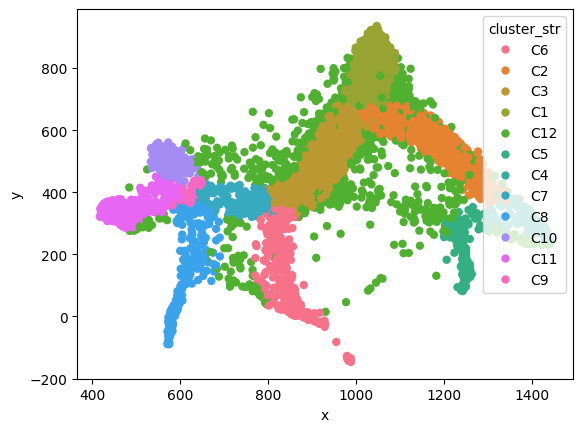

In [2]:
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/data/pellin_2019/PrincipalDevelopementalTrajectories/coordinates_sorted_HSPC_dataset_clustID.txt"

df = pd.read_csv(
    fpath, 
    header=None,
    names=['cell_id','x','y','cluster',]
)

print(f"{df.shape=}")
df['filter_pass'] = df['cluster'].notna()
df['cluster'] = df['cluster'].fillna('12')
df['cluster_str'] = "C" + df['cluster'].astype(int).astype(str)


sns.scatterplot(
    data=df, 
    x='x',
    y='y',
    ec='none',
    hue='cluster_str'
)

df['filter_pass'].value_counts()

In [3]:
# as anndata
adata = an.AnnData(
    X=df[['x', 'y']].to_numpy(), 
    obs=df,
)
adata.obsm['X_pca'] = adata.X.copy()
sc.pp.neighbors(adata)
adata

/home/cstansbu/miniconda3/envs/geneformer/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 6011 × 2
    obs: 'cell_id', 'x', 'y', 'cluster', 'filter_pass', 'cluster_str'
    uns: 'neighbors'
    obsm: 'X_pca'
    obsp: 'distances', 'connectivities'

In [4]:
filtered_adata = adata[adata.obs['filter_pass'], :].copy() # do not search low-quality cells

celnet = cn.CellNet(
    adata=filtered_adata,
    label_column='cluster',
    source_label=1,
    target_label=11,
    graph_n_components=2,
    distance_metric='euclidean',
    graph_neighbors=150,
    verbose=True,
)

source = "5961"
# target = celnet._random_target()
target = "5312"

path = celnet.find_path(source, target)
print(f"{source} --> {target} ({len(path)} steps)")

Neighbors calculation time: 0.4415 seconds
Graph creation time: 1.2703 seconds
Graph with 5163 nodes and 449696 edges
Graph built.

5961 --> 5312 (19 steps)


In [5]:
def make_colorbar(cmap='viridis', 
                  width=0.2,
                  height=2.5, 
                  title='', 
                  orientation='vertical', 
                  tick_labels=[0, 1]):
    
    a = np.array([[0, 1]])  # Dummy data for the image
    plt.figure(figsize=(width, height))
    img = plt.imshow(a, cmap=cmap)
    plt.gca().set_visible(False)  # Hide the axes of the image
    cax = plt.axes([0.1, 0.2, 0.8, 0.6])  # Define the colorbar position

    ticks = np.linspace(0, 1, len(tick_labels)) 
    cbar = plt.colorbar(
        orientation=orientation,
        cax=cax,
        label=title,
        ticks=ticks
    )

    if orientation == 'vertical':
        cbar.ax.set_yticklabels(tick_labels)
    elif orientation == 'horizontal':
        cbar.ax.set_xticklabels(tick_labels)

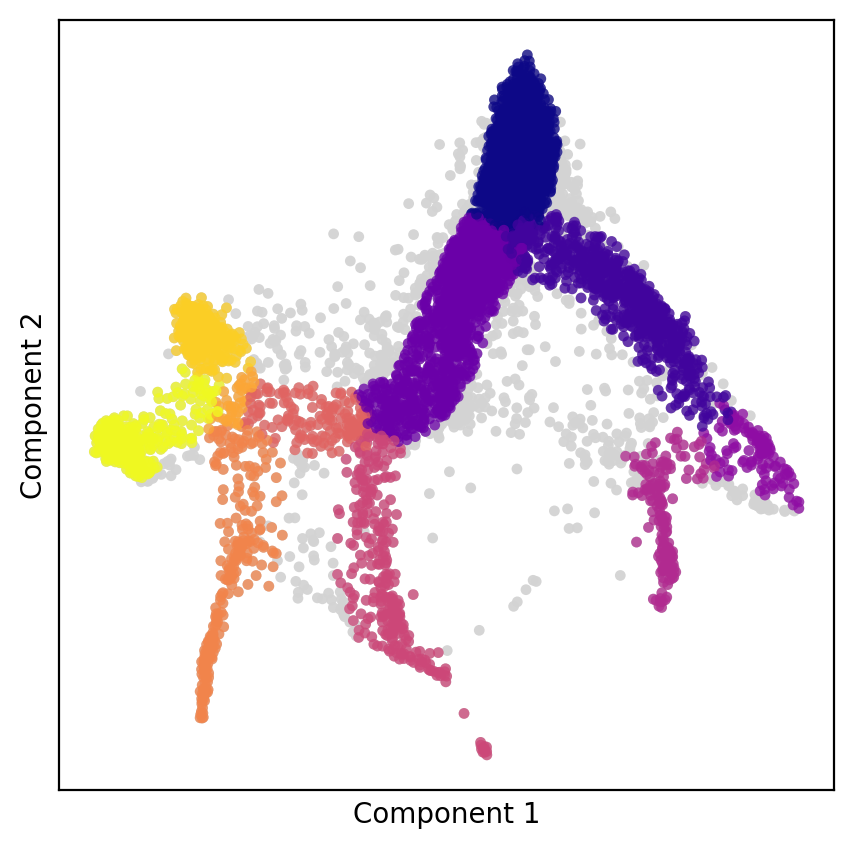

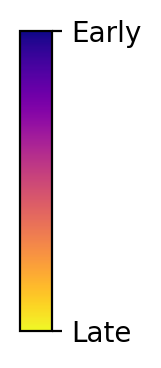

In [6]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 5

cmap='plasma'

sns.scatterplot(
    data=adata.obs,
    x='x',
    y='y',
    ec='none',
    s=15,
    c='lightgrey',
    alpha=0.95,
    legend=False,
)

sns.scatterplot(
    data=adata.obs[adata.obs['filter_pass']],
    x='x',
    y='y',
    hue='cluster',
    ec='none',
    s=15,
    palette=cmap,
    alpha=0.75,
    legend=False,
)

plt.xticks([])
plt.yticks([])

plt.ylabel('Component 2')
plt.xlabel('Component 1')
plt.show()

make_colorbar(cmap='plasma_r', tick_labels=['Late', 'Early'])


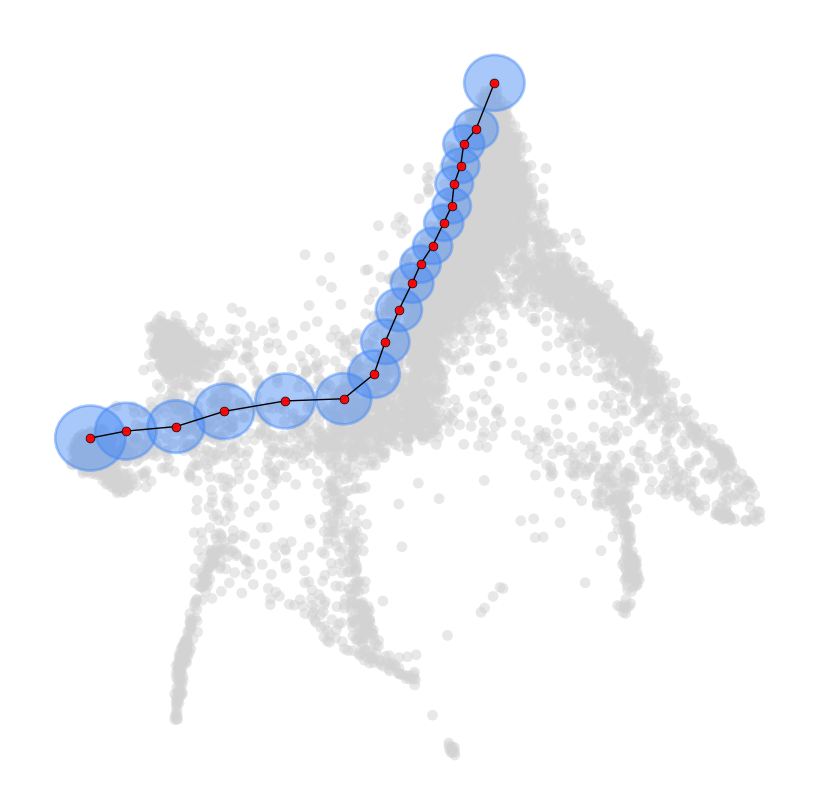

In [7]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 5

sns.scatterplot(
    data=adata.obs,
    x='x',
    y='y',
    c='lightgrey',
    ec='none',
    s=15,
    alpha=0.5,
    legend=False,
)

# plot cells on the path
traj = adata[path, :].copy()
sc.pp.neighbors(traj, n_neighbors=5)

sns.scatterplot(
    data=traj.obs,
    x='x',
    y='y',
    c='r',
    ec='k',
    lw=0.25,
    s=10,
    alpha=0.95,
    legend=False,
    zorder=5,
)

# Add circles based on nearest neighbor distances
distances = traj.obsp['distances'].todense() #convert sparse matrix to dense

for i in range(len(traj.obs)):
    nonzero_distances = distances[i][distances[i] > 0] 
    avg_distance = np.mean(nonzero_distances) 
    radius = np.sqrt(avg_distance)
    
    circle = plt.Circle(
        (traj.obs['x'].iloc[i], traj.obs['y'].iloc[i]),
        radius=radius*4,
        color='#4287f5', 
        alpha=0.45, 
        zorder=2, 
    )
    plt.gca().add_patch(circle) 



for i in range(len(traj.obs) - 1):
    plt.plot(
        [traj.obs['x'].iloc[i], traj.obs['x'].iloc[i + 1]],
        [traj.obs['y'].iloc[i], traj.obs['y'].iloc[i + 1]],
        color='k',
        linewidth=0.5,
        zorder=3, # keep lines behind the scatter points
    )


plt.xticks([])
plt.yticks([])

plt.ylabel('Component 2')
plt.xlabel('Component 1')
plt.gca().axis(False)
plt.show()

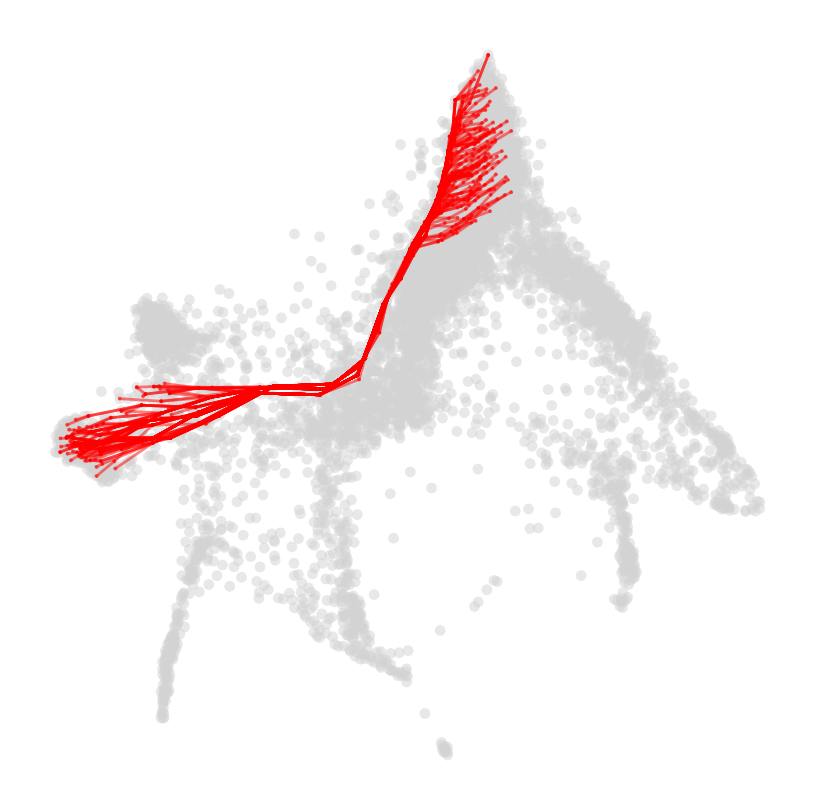

In [8]:
celnet.verbose = False
paths = celnet.get_random_paths(n_paths=100)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 5

sns.scatterplot(
    data=adata.obs,
    x='x',
    y='y',
    c='lightgrey',
    ec='none',
    s=15,
    alpha=0.5,
    legend=False,
)


for path in paths:

    # plot cells on the path
    traj = adata[path, :].copy()

    sns.scatterplot(
        data=traj.obs,
        x='x',
        y='y',
        c='r',
        ec='none',
        lw=0.25,
        s=2,
        alpha=0.5,
        legend=False,
        zorder=5,
    )

    for i in range(len(traj.obs) - 1):
        plt.plot(
            [traj.obs['x'].iloc[i], traj.obs['x'].iloc[i + 1]],
            [traj.obs['y'].iloc[i], traj.obs['y'].iloc[i + 1]],
            color='r',
            linewidth=1,
            alpha=0.5,
            zorder=3,
        )
    # break


plt.gca().axis(False)
plt.show()

In [9]:
adata

AnnData object with n_obs × n_vars = 6011 × 2
    obs: 'cell_id', 'x', 'y', 'cluster', 'filter_pass', 'cluster_str'
    uns: 'neighbors'
    obsm: 'X_pca'
    obsp: 'distances', 'connectivities'

In [10]:
adata.obs.head()

,cell_id,x,y,cluster,filter_pass,cluster_str
0,0,987.804741,-134.381058,6.0,True,C6
1,1,1039.458618,676.463268,2.0,True,C2
2,2,995.956820,540.567363,3.0,True,C3
3,3,1046.799111,751.983179,1.0,True,C1
4,4,1050.351630,765.608421,1.0,True,C1


# Load data

In [11]:
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/data/pellin_2019/pellin.anndata.h5ad"
adata = sc.read_h5ad(fpath)
adata.obs['cell_type'] = adata.obs['dataset']
adata.var_name = adata.var['gene_name']
adata.X = adata.layers['raw_counts']

# drop lineage negative cells?
adata = adata[~adata.obs['cell_type'].str.startswith('LinNeg'), :].copy()

adata.obs.head()

,Barcode,Library,dataset,cell_type
cell_id,,,,
PreBNK_AGTTGAAC-TTGCATAT_1,AGTTGAAC-TTGCATAT,1,PreBNK,PreBNK
PreBNK_AATCCGGC-TGAAATGA_1,AATCCGGC-TGAAATGA,1,PreBNK,PreBNK
PreBNK_CAAACATT-TCTGTGGT_1,CAAACATT-TCTGTGGT,1,PreBNK,PreBNK
PreBNK_AATCGAAG-AGTGAAAG_1,AATCGAAG-AGTGAAAG,1,PreBNK,PreBNK
PreBNK_CGTGTACA-TTCCAGAC_1,CGTGTACA-TTCCAGAC,1,PreBNK,PreBNK


In [12]:
adata.obs['cell_type'].value_counts()

cell_type
CMP       1576
HSC       1282
MEP       1211
GMP       1012
PreBNK     592
MPP        215
MLP        123
Name: count, dtype: int64

# Filtering

In [13]:
sc.pp.filter_cells(adata, min_counts=200)
sc.pp.filter_genes(adata, min_counts=50)

adata.layers['raw'] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata

AnnData object with n_obs × n_vars = 6011 × 11380
    obs: 'Barcode', 'Library', 'dataset', 'cell_type', 'n_counts'
    var: 'gene_name', 'n_counts'
    uns: 'log1p'
    layers: 'raw_counts', 'raw'

Number of genes before HVG selection: 11380
Number of genes after HVG selection: 2500


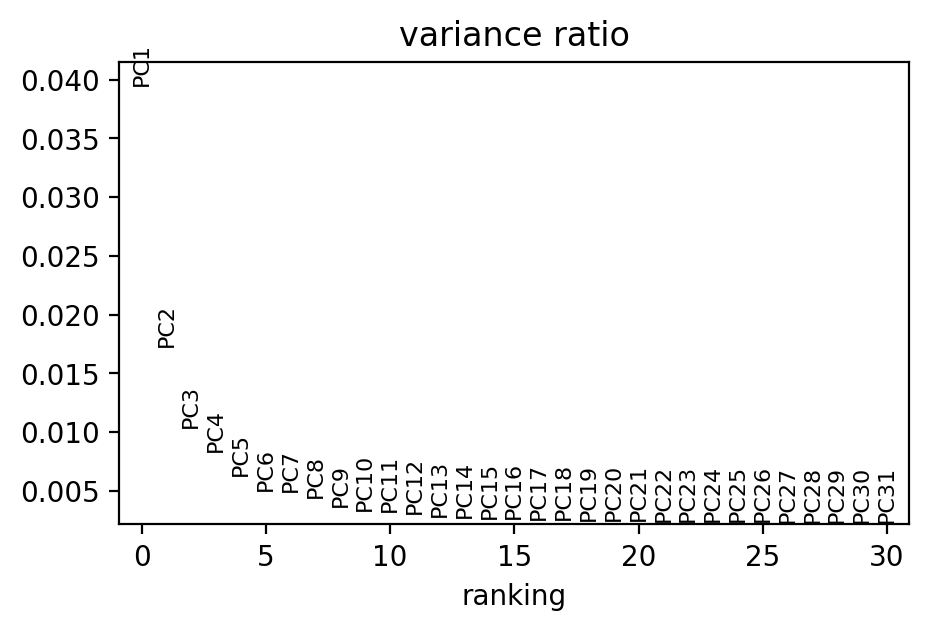

AnnData object with n_obs × n_vars = 6011 × 2500
    obs: 'Barcode', 'Library', 'dataset', 'cell_type', 'n_counts'
    var: 'gene_name', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'raw_counts', 'raw', 'log_norm'

In [14]:
adata.raw = adata  # keep full dimension safe
print(f"Number of genes before HVG selection: {adata.n_vars}")
sc.pp.highly_variable_genes(
    adata,
    flavor="seurat_v3",
    n_top_genes=2500,
    layer="raw_counts",
    subset=True,
)
print(f"Number of genes after HVG selection: {adata.n_vars}")

# ONLY keep HVGs
adata = adata[:,adata.var["highly_variable"] == True].copy()

sc.pp.pca(
    adata,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3

sc.pl.pca_variance_ratio(
    adata
)

adata.layers['log_norm'] = adata.X.copy()
adata

In [15]:
# sc.pp.neighbors(
#     adata,
#     n_neighbors=150,
# )


# sce.tl.phate(
#     adata, 
#     knn=35,
#     a=100,
#     n_pca=25,
#     mds='metric',
# )
# print(f"{adata.obsm['X_phate'].shape=}")

# adata.obs['phate 1'] = adata.obsm['X_phate'][:, 1]
# adata.obs['phate 2'] = adata.obsm['X_phate'][:, 0]
# adata.uns['pellin_coords'] = df[['x', 'y']].to_numpy()
# adata.uns['pellin_metadata'] = df.copy()

# plt.rcParams['figure.dpi'] = 200
# plt.rcParams['figure.figsize'] = 4, 4

# sce.pl.phate(
#     adata,
#     color='cell_type'
# )

# Imputation

In [16]:
# sc.external.pp.dca(adata)

sce.pp.magic(adata, solver='approximate')
adata.layers['magic'] = adata.X.copy()
adata.X = adata.layers['log_norm'].copy()
adata

AnnData object with n_obs × n_vars = 6011 × 2500
    obs: 'Barcode', 'Library', 'dataset', 'cell_type', 'n_counts'
    var: 'gene_name', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'raw_counts', 'raw', 'log_norm', 'magic'

In [17]:
celnet = cn.CellNet(
    adata=adata,
    label_column='cell_type',
    source_label='HSC',
    target_label='PreBNK',
    graph_n_components=2,
    distance_metric='euclidean',
    graph_neighbors=55,
    verbose=True,
)

paths = celnet.get_random_paths(n_paths=10)
paths[0]

Neighbors calculation time: 0.4181 seconds
Graph creation time: 0.5283 seconds
Graph with 6011 nodes and 184993 edges
Graph built.

Path 1 (37 nodes) generated in 2.2900 seconds.
Path 2 (9 nodes) generated in 0.6266 seconds.
Path 3 (35 nodes) generated in 1.7568 seconds.
Path 4 (21 nodes) generated in 2.8196 seconds.
Path 5 (15 nodes) generated in 0.8339 seconds.
Path 6 (21 nodes) generated in 1.9920 seconds.
Path 7 (20 nodes) generated in 2.0015 seconds.
Path 8 (19 nodes) generated in 1.0779 seconds.
Path 9 (25 nodes) generated in 1.3015 seconds.
Path 10 (32 nodes) generated in 1.4827 seconds.


['HSC_TGTTATCA-CCCGACTT_1',
 'CMP_ATCCCACC-CACTCCTC_1',
 'MPP_ACGACGAC-TGCAAGGG_1',
 'MEP_TAAGGGCC-GAAGTGCC_1',
 'HSC_CGAAGAAG-TACAGCCG_1',
 'HSC_AAAGCCCG-AAACCTCC_1',
 'MEP_GGAGTAAG-ATTGGGCC_1',
 'MEP_TAGTAGCC-ATCCCACG_1',
 'MEP_TCCGACAC-TACAGCCG_1',
 'CMP_AAGAAGGT-ATGTTGGC_1',
 'MPP_GTTGTCCG-TACTTGTG_1',
 'HSC_AAGTATTG-AGCACCAC_1',
 'HSC_CTACGGGA-TTTATCAC_1',
 'CMP_AGTTGCGG-AAGCGTAC_1',
 'CMP_TGGAAAGC-CGGGTAGT_1',
 'HSC_CCCTGTTT-GTTACCGC_1',
 'CMP_AAAGAAAG-CCCATAGC_1',
 'CMP_AGTTGAAC-GAGCGGTA_1',
 'CMP_GGAACGAA-AATGTTTG_1',
 'CMP_AATGGCGT-CACAAGGC_1',
 'CMP_TATTAGCG-TACGTGCT_1',
 'CMP_AGTCCGTG-ACCCATAT_1',
 'CMP_AAGTGAGA-GTATGAGT_1',
 'PreBNK_AGAGGTGC-GATCGTTT_1',
 'CMP_ACGAATTC-TTAAGCGT_1',
 'PreBNK_AACTGCCT-GCTTACCT_1',
 'PreBNK_GTATACGT-ACTGAGTT_1',
 'GMP_AGTCCGTG-TCACCGAG_1',
 'PreBNK_AAGTATTG-CGAGTCTG_1',
 'PreBNK_ACTCGGAA-CGAGATGT_1',
 'PreBNK_GCAAACTG-GAGGCTGA_1',
 'GMP_AGCATGCC-AGCACCAC_1',
 'PreBNK_AAGAGTAT-AGGCAGTT_1',
 'PreBNK_CATGACGA-CTTCGCAC_1',
 'PreBNK_TAACTTCT-AGACAC

# Predict Step

In [18]:
layer = 'magic'

train_data = []
label_data = []

for i, path in enumerate(paths):

    x = adata[path, :].layers[layer].toarray()
    y = np.linspace(0, 1, len(path))

    train_data.append(x)
    label_data.append(y)
    

train_data = np.vstack(train_data)
label_data = np.hstack(label_data)
print(f"{train_data.shape=}")

print(f"{label_data.shape=}")

train_data.shape=(234, 2500)
label_data.shape=(234,)


R² score: 0.7834
RMSE: 0.1276


/tmp/ipykernel_2388549/1622293538.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


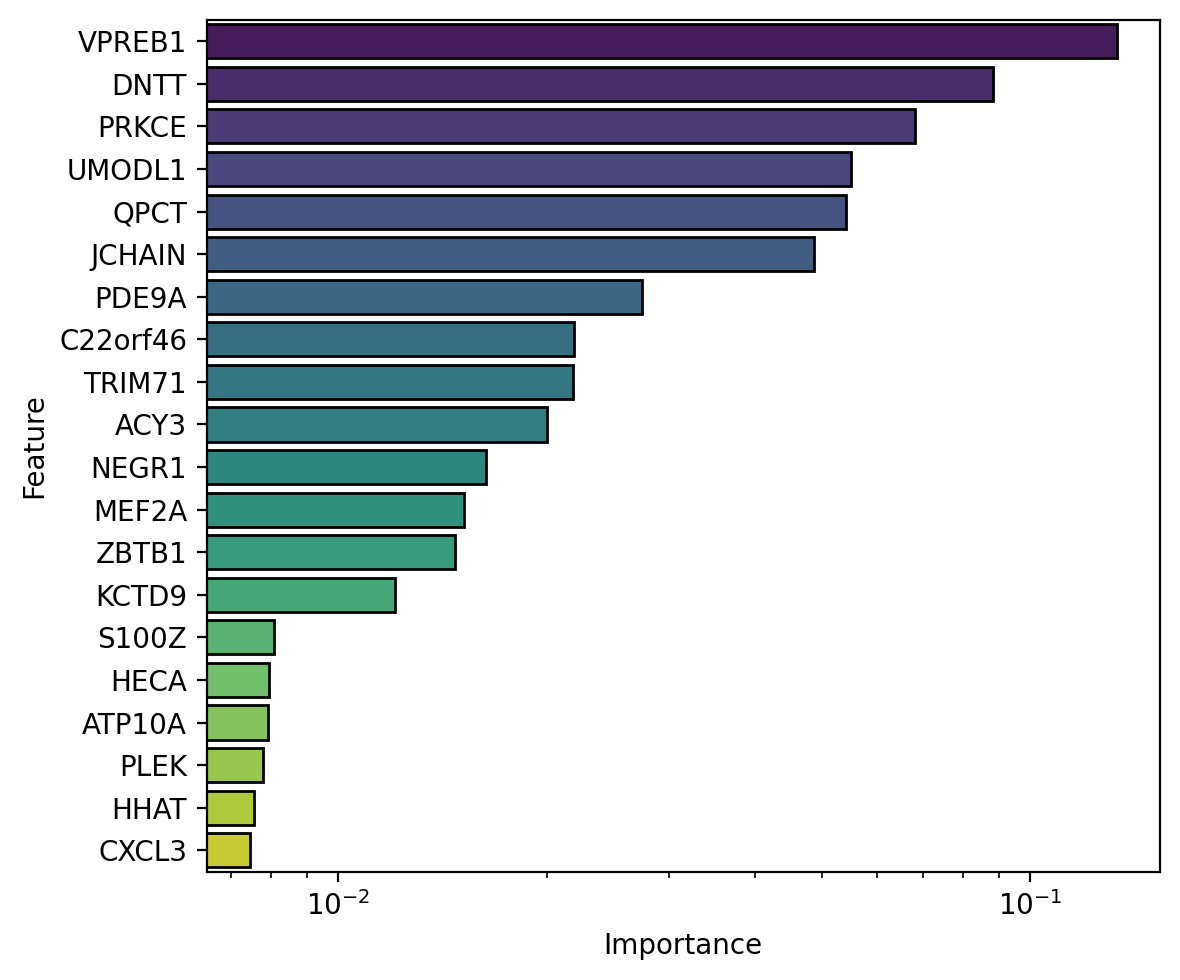

In [19]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(train_data, label_data, test_size=0.2, random_state=42)

# Fit the Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# Set number of top features to plot
n = 20

# Create a DataFrame of feature importances
feature_df = pd.DataFrame({
    "gene_name" : adata.var_names,
    "feature" : [f"Feature_{i}" for i in range(train_data.shape[1])],
    "importance" : model.feature_importances_,
})

# Sort and select top n
top_features = feature_df.sort_values("importance", ascending=False).head(n)

# Seaborn barplot

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 5

sns.barplot(
    data=top_features, 
    x="importance", 
    y="gene_name", 
    ec='k',
    palette="viridis")

plt.xscale('log')

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
n = 25
gene_list = feature_df.sort_values("importance", ascending=False).head(n)['gene_name'].to_list()

edf = gget.enrichr(gene_list, database='ontology')
edf.head()


16:37:54 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2021. 
        Please note that there might be a more appropriate database for your application. 
        Go to https://maayanlab.cloud/Enrichr/#libraries for a full list of supported databases.
        


In [20]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
break

In [ ]:
def sequence_expression(adata, path, layer=None):
    if layer is None:
        tdf = adata[path, :].to_df()
    else:
        tdf = adata[path, :].to_df(layer=layer)

    time_vector = np.array(range(len(tdf))).reshape(-1, 1)
    D = cdist(
        tdf.to_numpy().T, 
        time_vector.T, 
        metric='correlation',
    )
    D = D - 1
    D = pd.DataFrame(D, index=tdf.columns, columns=['correlation'])
    D = D.reset_index()
    return D

result = []

for i, path in enumerate(paths):
    tdf = sequence_expression(adata, path, layer='magic')
    tdf['path'] = i + 1
    result.append(tdf)

result = pd.concat(result)
result = result.groupby(['var_name']).agg(
    mean=('correlation', 'mean'),
    std=('correlation', 'std'),
).reset_index()

result = result.sort_values(by='mean')
# top = 10

# result = pd.concat([result.head(top), result.tail(top)])
print(f"{result.shape=}")
result.head()

In [ ]:
def unique_nested(lst):
  s = set()
  def f(l):
    for i in l:
      if isinstance(i, list): f(i)
      else: s.add(i)
  f(lst)
  return list(s)

cell_ids = unique_nested(paths)
print(f"{len(cell_ids)=}")
pdf = adata[cell_ids, result['var_name'].values].to_df(layer='magic')
print(f"{pdf.shape=}")

pdf = pdf.reset_index(drop=True).T

sns.heatmap(
    data=pdf,
    # square=True,
    cbar_kws={'shrink' : 0.4}
)


In [ ]:
break

In [ ]:
300 * (4 * 60)

In [ ]:
break

In [ ]:
gene_list = [
    'VIM',
    'RUNX2',
    'ANXA1',
    'CXCR4',
    'HOXA9',
    'GATA2',
    'ID2',
    'IL1B',
    'JUN',
    'ITGB2',
    'JUNB',
    'KIT',
    'KLF2',
    'KLF4',
    'LYZ',
    'MEF2A',
    'MMP11',
    'MPO',
    'IRF8',
    'MYC',
]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 10, 4

traj = adata[paths[0], :].copy()
traj.X = traj.layers['magic'].copy()
pdf = traj[:, gene_list].to_df().reset_index(drop=True).T

row_means = pdf.mean(axis=0)  
pdf = pdf.sub(row_means, axis=1)  

sns.heatmap(
    data=pdf,
    # square=True,
    cbar_kws={'shrink' : 0.4}
)


In [ ]:
break

In [ ]:
?sns.clustermap

In [ ]:
break

In [ ]:
# break

In [ ]:
# """ TABULA SAPIENS BLOOD """
# fpath = "/nfs/turbo/umms-indikar/shared/projects/DGC/data/tabula_sapiens/extract/TS_Blood.h5ad"
# adata = sc.read_h5ad(fpath)
# adata.obs['cell_type'] = adata.obs['free_annotation']
# adata.obs['tissue'] = adata.obs['organ_tissue']
# adata.X = adata.layers['raw_counts']

# """ SUBSAMPLING """
# fraction = 0.35
# adata = sc.pp.sample(adata, fraction=fraction, copy=True)

# adata

In [ ]:
sc.pp.filter_cells(adata, min_counts=200)
sc.pp.filter_genes(adata, min_counts=50)

adata.layers['raw'] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata

In [ ]:
adata.raw = adata  # keep full dimension safe
print(f"Number of genes before HVG selection: {adata.n_vars}")
sc.pp.highly_variable_genes(
    adata,
    flavor="seurat_v3",
    n_top_genes=2500,
    layer="raw_counts",
    subset=True,
)
print(f"Number of genes after HVG selection: {adata.n_vars}")

# ONLY keep HVGs
adata = adata[:,adata.var["highly_variable"] == True].copy()

sc.pp.pca(
    adata,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3

sc.pl.pca_variance_ratio(
    adata
)

sc.pp.neighbors(
    adata,
    n_neighbors=150,
)

sce.tl.palantir(
    adata, 
    n_components=55, 
    knn=55,
)

sc.pp.neighbors(
    adata,
    n_neighbors=25,
    use_rep='X_palantir_multiscale',
)

sc.tl.umap(
    adata,
    min_dist=0.9,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata, 
    color="cell_type",
)

# Palantir

In [ ]:
sce.tl.palantir(
    adata, 
    n_components=55, 
    knn=55,
)

sc.pp.neighbors(
    adata,
    n_neighbors=25,
    use_rep='X_palantir_multiscale',
)

sc.tl.umap(
    adata,
    min_dist=0.9,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata, 
    color="cell_type",
)

In [ ]:
break

In [ ]:
# Provided 

# PHATE

In [ ]:
sce.tl.phate(
    adata, 
    knn=35,
    a=100,
    n_pca=25,
    mds='metric',
)
print(f"{adata.obsm['X_phate'].shape=}")

adata.obs['phate 1'] = adata.obsm['X_phate'][:, 1]
adata.obs['phate 2'] = adata.obsm['X_phate'][:, 0]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sce.pl.phate(
    adata,
    color='cell_type'
)

# Plotting Nicely

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 5

sns.scatterplot(
    data=adata.obs,
    x='phate 1',
    y='phate 2',
    s=5,
    ec='none',
    hue='cell_type',
)

plt.xticks([])
plt.yticks([])

sns.move_legend(
    plt.gca(),
    title='',
    loc='center right',
    markerscale=1.5,
    bbox_to_anchor=(1.4, 0.5),
)



In [ ]:
break

# Palantir

In [ ]:
sce.tl.palantir(
    adata, 
    n_components=55, 
    knn=55,
)

sc.pp.neighbors(
    adata,
    n_neighbors=25,
    use_rep='X_palantir_multiscale',
)

sc.tl.umap(
    adata,
    min_dist=0.9,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata, 
    color="cell_type",
)

In [ ]:
break

In [ ]:
start_cell = adata.obs[adata.obs['cell_type'] == 'HSC'].sample(1).index[0]

pr_res = sce.tl.palantir_results(
    adata,
    early_cell=start_cell,
    ms_data='X_palantir_multiscale',
    num_waypoints=500,
)

type(pr_res)

In [ ]:
adata

In [ ]:
break

In [ ]:
dir(pr_res)

In [ ]:
sce.tl.palantir(
    adata, 
    n_components=15, 
    knn=30,
)

sc.tl.tsne(
    adata, 
    n_pcs=2,
    use_rep='X_palantir_multiscale',
    perplexity=150,
)

sc.pl.tsne(
    adata, 
    color="cell_type",
)

In [ ]:
break

In [ ]:
bdata = sc.datasets.paul15()

bdata.raw = bdata  # keep full dimension safe
print(f"Number of genes before HVG selection: {bdata.n_vars}")
sc.pp.highly_variable_genes(
    bdata,
    flavor="seurat_v3",
    subset=True,
)
print(f"Number of genes after HVG selection: {bdata.n_vars}")

sc.pp.pca(
    bdata,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3

sc.pl.pca_variance_ratio(
    bdata
)

sc.pp.neighbors(
    bdata,
    n_neighbors=55,
)

bdata

In [ ]:
break

In [ ]:
sce.tl.phate(
    bdata, 
    knn=15,
    n_pca=25,
    mds='nonmetric',
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 5

sce.pl.phate(
    bdata,
    color='paul15_clusters'
)